<a href="https://colab.research.google.com/github/Rp2451/practice-projects/blob/main/05-Data-Visualization/Non-Guided-Project/NG05_Sports_Performance_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NG05: Sports Performance Dashboard 🏀📊
## CAI1001C: Artificial Intelligence Thinking — Non-Guided Project 5

**Graded Assignment**

---

### Overview

In GP05, you built visualizations using Miami weather, shipping, housing, and tourism data. Now it's your turn to apply those same skills to a **sports dataset** — same techniques, new context.

You will create **3 visualizations** from a provided sports dataset, each answering a different question, with a **1-paragraph interpretation** for each chart.

### Instructions

1. Download the dataset CSV from the course GitHub repository (link below)
2. Upload it to Google Colab or place it in your working directory
3. Complete **Tasks 1–3** by writing code in the provided cells
4. Write your interpretation in the markdown cells after each task
5. (Optional) Complete the **Bonus Challenge** for extra credit
6. Save and submit your completed notebook

**Dataset Options:**
- **Default**: Use the NBA player stats dataset provided (recommended for beginners)
- **Choose Your Own**: If you have experience, you may substitute any sports dataset (CSV) of your choice. Your dataset must have at least 5 columns and 50+ rows. If you choose your own, adjust your tasks accordingly.

### Grading Criteria

| Component | Points | What I'm Looking For |
|-----------|--------|---------------------|
| **Task 1**: Matplotlib chart (bar or line) | 25 | Correct chart type for the question, proper labels/title, at least one annotation |
| **Task 1 Interpretation** | 10 | 2–3 sentences that correctly describe what the chart reveals |
| **Task 2**: Matplotlib multi-chart layout | 25 | Two charts side-by-side using `plt.subplots()`, different chart types, full customization |
| **Task 2 Interpretation** | 10 | 2–3 sentences per chart explaining what each reveals |
| **Task 3**: Seaborn statistical chart | 20 | Appropriate Seaborn chart type (heatmap, box plot, or scatter), correct data selection |
| **Task 3 Interpretation** | 10 | 2–3 sentences describing the relationship or pattern shown |
| **Bonus Challenge** | +10 | 4th visualization that reveals something the other three miss, with explanation |
| **Total** | 100 (+10 bonus) | |

---


## Setup & Dataset

### Step 1: Run the setup cell below to import libraries

### Step 2: Download the dataset
Download `nba_player_stats_2024.csv` from the course GitHub repository:

👉 **[REPLACE WITH YOUR GITHUB URL]**

`https://raw.githubusercontent.com/c-marq/AI-Thinking-CAI1001C/refs/heads/main/05-Data-Visualization/Datasets/nba_player_stats_2024.csv`

### Step 3: Load the dataset
- **Option A (Google Colab):** Upload the CSV using the file browser on the left sidebar, then run the loading cell
- **Option B (Direct URL):** If the GitHub link works, you can load directly from the URL

### Dataset Columns
| Column | Description |
|--------|------------|
| `Player` | Player name |
| `Team` | Team abbreviation (MIA, BOS, LAL, etc.) |
| `Position` | Playing position (PG, SG, SF, PF, C) |
| `Games` | Number of games played this season |
| `Points_Per_Game` | Average points scored per game |
| `Rebounds_Per_Game` | Average rebounds per game |
| `Assists_Per_Game` | Average assists per game |
| `Steals_Per_Game` | Average steals per game |
| `FG_Pct` | Field goal percentage (0–1 scale) |
| `Three_Pct` | Three-point shooting percentage (0–1 scale) |
| `Minutes_Per_Game` | Average minutes played per game |


In [7]:
# ============================================
# Setup: Import all required libraries
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set a clean visual theme for all charts
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [8]:
# ============================================
# Load the dataset
# ============================================

# OPTION A: If you uploaded the CSV to Colab, use this:
df = pd.read_csv('nba_player_stats_2024.csv')

# OPTION B: If loading directly from GitHub, uncomment and use this instead:
# url = 'https://raw.githubusercontent.com/c-marq/AI-Thinking-CAI1001C/refs/heads/main/05-Data-Visualization/Datasets/nba_player_stats_2024.csv'
# df = pd.read_csv(url)

print(f"✅ Dataset loaded: {len(df)} players across {df['Team'].nunique()} teams")
print(f"   Positions: {', '.join(sorted(df['Position'].unique()))}")
print(f"   Points range: {df['Points_Per_Game'].min()} — {df['Points_Per_Game'].max()} PPG")
print()
print(df.head(10))

✅ Dataset loaded: 80 players across 16 teams
   Positions: C, PF, PG, SF, SG
   Points range: 6.3 — 35.2 PPG

              Player Team Position  Games  Points_Per_Game  Rebounds_Per_Game  \
0     Marcus Johnson  ATL       PG     77             25.5                1.2   
1    Jaylen Williams  MIL       SF     54             18.4                4.7   
2       Damian Brown  NYK        C     67             17.5                4.9   
3      Anthony Davis  MIN       PF     67             15.1                4.3   
4     Kevin Thompson  SAC       PG     46             26.3                2.5   
5     Devin Mitchell  DEN        C     68             28.2                8.8   
6       Jamal Murray  SAC       SG     77             16.2                4.4   
7  Tyrese Haliburton  MIN        C     61             33.0                9.9   
8        Jalen Green  PHX       PF     80             16.2                3.6   
9        Darius King  LAL       SG     73             30.4                5.9   

## Step 2: Explore the Data

Before creating any charts, take a few minutes to understand what you're working with. Run the cell below to see summary statistics. This will help you decide what questions to ask and which chart types to use.


In [9]:
# Explore the dataset — run this cell to understand your data
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()

print("=== Data Types ===")
print(df.dtypes)
print()

print("=== Summary Statistics ===")
print(df.describe().round(2))
print()

print("=== Players Per Position ===")
print(df['Position'].value_counts())
print()

print("=== Players Per Team (top 5) ===")
print(df['Team'].value_counts().head())

=== Dataset Shape ===
Rows: 80, Columns: 11

=== Data Types ===
Player                object
Team                  object
Position              object
Games                  int64
Points_Per_Game      float64
Rebounds_Per_Game    float64
Assists_Per_Game     float64
Steals_Per_Game      float64
FG_Pct               float64
Three_Pct            float64
Minutes_Per_Game     float64
dtype: object

=== Summary Statistics ===
       Games  Points_Per_Game  Rebounds_Per_Game  Assists_Per_Game  \
count  80.00            80.00              80.00             80.00   
mean   63.69            18.23               5.02              3.51   
std     9.81             6.52               2.65              2.24   
min    45.00             6.30               1.20              0.50   
25%    55.75            13.60               3.18              1.88   
50%    64.00            17.55               4.60              3.40   
75%    71.25            22.42               5.98              4.43   
max    80.00   

---

## Task 1: Matplotlib Chart — Compare a Statistic Across Groups (25 pts)

**Create a bar chart OR line chart** that answers one of the following questions (choose one):

- Which **positions** score the most points per game on average?
- Which **teams** have the highest average assists per game?
- How does **field goal percentage** compare across positions?

**Requirements:**
- Use Matplotlib (`plt.bar()` or `plt.plot()`)
- Include a descriptive title
- Label both axes
- Add at least one annotation (e.g., label the highest bar, add a reference line)
- Choose colors that are easy to read

**Hint from GP05:** Look at how we built the bar chart in Example 2 — grouping data and adding value labels on top. You'll want to use `df.groupby()` from Chapter 4 to calculate averages by group.


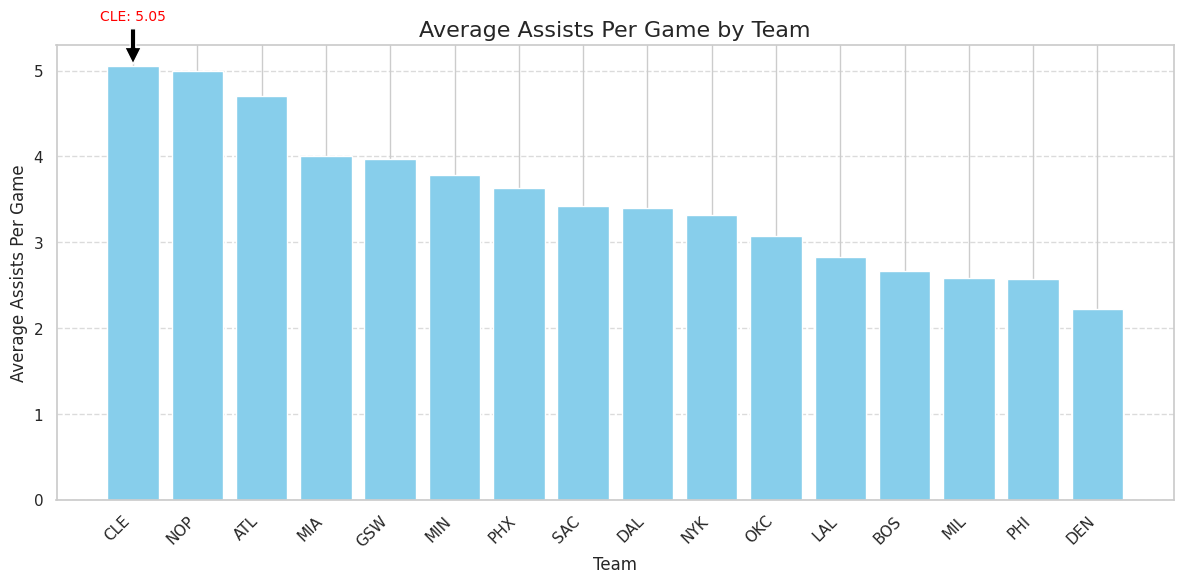

In [10]:
# ============================================
# Task 1: Your Matplotlib Chart
# ============================================

# Step 1: Group the data and calculate averages
avg_assists_by_team = df.groupby('Team')['Assists_Per_Game'].mean().sort_values(ascending=False)

# Step 2: Create the chart
plt.figure(figsize=(12, 6))
bars = plt.bar(avg_assists_by_team.index, avg_assists_by_team.values, color='skyblue')

# Step 3: Add labels, title, and annotation
plt.title('Average Assists Per Game by Team', fontsize=16)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Average Assists Per Game', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add annotation for the highest value
highest_team = avg_assists_by_team.index[0]
highest_assists = avg_assists_by_team.values[0]
plt.annotate(f'{highest_team}: {highest_assists:.2f}',
             xy=(highest_team, highest_assists),
             xytext=(highest_team, highest_assists + 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='center', va='bottom', fontsize=10, color='red')

plt.tight_layout()
plt.show()

### Task 1 Interpretation (10 pts)

**Write 2–3 sentences explaining what your chart reveals.** What pattern do you see? Is anything surprising? What might explain the differences?

*(Double-click this cell to edit, then type your interpretation)*

YOUR INTERPRETATION HERE:




the first two teams are pretty similar, then the third drops, and the pattern reoccurs. For the first two staying the same, then the third dropping, the next two are lower but together pretty similar. the fact that there is a tendency like this in general is a bit surprising if not odd to me.

---

## Task 2: Matplotlib Multi-Chart Layout (25 pts)

**Create two charts side-by-side** using `plt.subplots(1, 2)`. Each chart must:
- Use a **different chart type** (e.g., one bar chart and one histogram, or one line chart and one bar chart)
- Answer a **different question** than Task 1

**Suggested combinations** (choose one pair or make your own):
- **Bar chart** of average rebounds by position + **Histogram** of points per game distribution
- **Bar chart** of top 10 scorers + **Histogram** of minutes played distribution
- **Bar chart** of average steals by team (top 8) + **Histogram** of field goal percentages

**Requirements:**
- Use `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))`
- Each chart needs a title and axis labels
- Use `plt.tight_layout()` to prevent overlapping
- Use different colors for each chart

**Hint from GP05:** Refer to Example 2 where we built the 3-panel shipping dashboard. The pattern is the same — just 2 panels instead of 3.


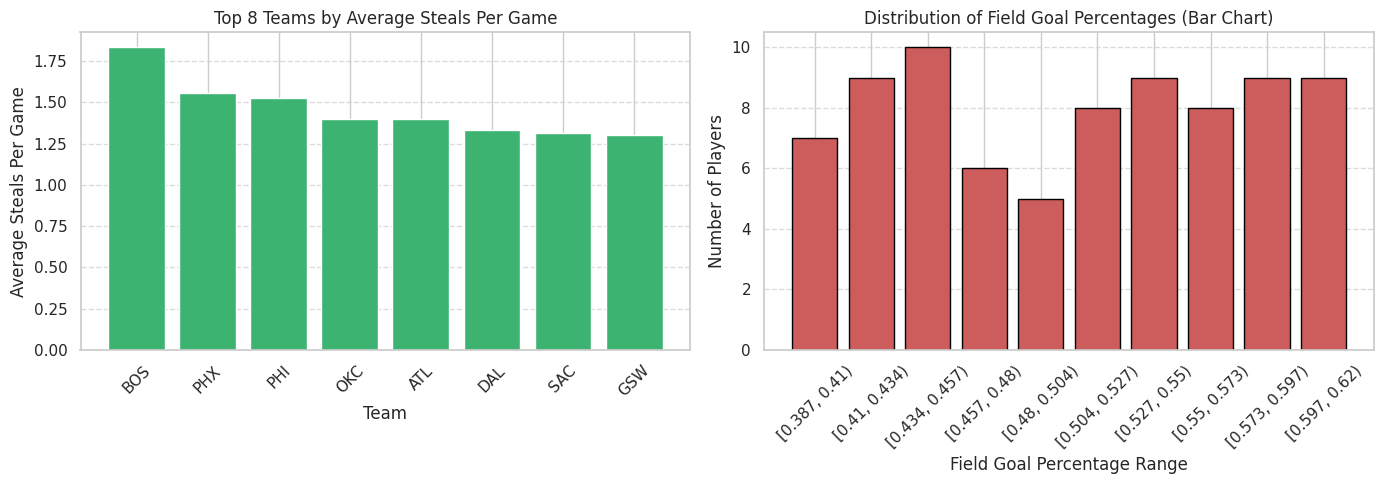

In [12]:
# ============================================
# Task 2: Two Charts Side-by-Side
# ============================================

# Create the figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Bar chart of average steals by team (top 8) ---
# Calculate average steals per game by team, sort, and take the top 8
avg_steals_by_team = df.groupby('Team')['Steals_Per_Game'].mean().sort_values(ascending=False).head(8)

ax1.bar(avg_steals_by_team.index, avg_steals_by_team.values, color='mediumseagreen')
ax1.set_title('Top 8 Teams by Average Steals Per Game')
ax1.set_xlabel('Team')
ax1.set_ylabel('Average Steals Per Game')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Chart 2: Bar chart of field goal percentages distribution ---
# Discretize FG_Pct into bins and count occurrences for a bar chart representation
fg_pct_bins = pd.cut(df['FG_Pct'], bins=10, right=False) # Create 10 bins
fg_pct_counts = fg_pct_bins.value_counts().sort_index() # Count players in each bin and sort by bin

ax2.bar(fg_pct_counts.index.astype(str), fg_pct_counts.values, color='indianred', edgecolor='black')
ax2.set_title('Distribution of Field Goal Percentages (Bar Chart)')
ax2.set_xlabel('Field Goal Percentage Range')
ax2.set_ylabel('Number of Players')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Task 2 Interpretation (10 pts)

**Write 2–3 sentences for EACH chart** (4–6 sentences total). What does each chart reveal? How do the two charts complement each other — do they tell different parts of the same story?

*(Double-click this cell to edit)*

**Chart 1 interpretation:**

YOUR INTERPRETATION HERE: the first chart actually looks pretty similar to the previous chart made for average assists made. I dont know what this really means in sports terms, maybe that the assists and steals are highly corrolated, but I wouldn't know as I do not get too much into sports.

**Chart 2 interpretation:**

YOUR INTERPRETATION HERE:
the second oneis a bit harder to read just because i've had a hard time getting the values for a histogram to work, and using a bar chart doesn't quite fit for this, so i'm not sure how to read this.


---

## Task 3: Seaborn Statistical Chart (20 pts)

**Create one Seaborn visualization** that reveals a relationship or pattern in the data. Choose one:

- **Scatter plot** (`sns.scatterplot`): How do points per game relate to minutes played? Color by position.
- **Box plot** (`sns.boxplot`): How does points per game distribution differ by position?
- **Heatmap** (`sns.heatmap`): Which numerical stats are most correlated with each other?

**Requirements:**
- Use a Seaborn function (not Matplotlib)
- Include a clear title
- If using a scatter plot, use the `hue` parameter to color-code by a categorical variable
- If using a heatmap, select only numeric columns and use `annot=True`

**Hint from GP05:** Refer to Example 3 where we built the housing analysis. The Seaborn syntax is nearly identical — just swap in sports columns.


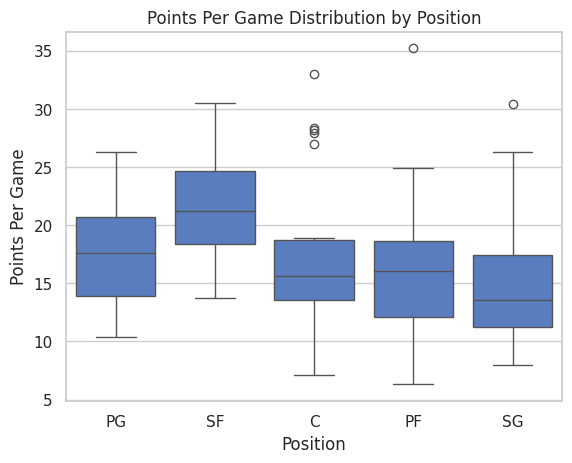

In [14]:
# ============================================
# Task 3: Your Seaborn Visualization
# ============================================

sns.boxplot(data=df, x='Position', y='Points_Per_Game')
plt.title('Points Per Game Distribution by Position')
plt.xlabel('Position')
plt.ylabel('Points Per Game')
plt.show()

### Task 3 Interpretation (10 pts)

**Write 2–3 sentences explaining what your chart reveals.** If you made a scatter plot, describe the relationship. If a box plot, compare the distributions. If a heatmap, identify the strongest and weakest correlations.

*(Double-click this cell to edit)*

YOUR INTERPRETATION HERE:




---

## 🌟 Bonus Challenge (Optional — +10 pts)

**Create a 4th visualization that tells a story the other three miss.**

This is deliberately open-ended. Think about what questions your first three charts *didn't* answer. Some ideas:
- A chart comparing two stats you haven't looked at yet
- A visualization that filters to a specific subset (e.g., just centers, just one team)
- A chart that combines multiple variables in a way that reveals something unexpected

**Requirements:**
- Must be a different chart type OR answer a meaningfully different question than Tasks 1–3
- Include a title and labels
- Write a **3–4 sentence explanation** of:
  1. Why you chose this chart type
  2. What story it tells that the other three missed


In [ ]:
# ============================================
# Bonus: Your 4th Visualization
# ============================================

# YOUR CODE HERE:


plt.show()

### Bonus Interpretation

**Why did you choose this chart type? What story does it tell that the other three missed?**

*(Double-click this cell to edit)*

YOUR EXPLANATION HERE:




---

## Submission Instructions

1. **Run all cells** one final time from top to bottom to make sure everything works
   - Go to: `Runtime` → `Run all`
   - Fix any errors before submitting
2. **Check** that all interpretation cells have been filled in (not just "YOUR INTERPRETATION HERE")
3. **Save** your notebook: `File` → `Save` (or Ctrl+S)
4. **Download** as .ipynb: `File` → `Download` → `Download .ipynb`
5. **Upload** the .ipynb file to the course assignment portal

### Before You Submit Checklist

- [ ] Task 1: Chart displays correctly with title, labels, and annotation
- [ ] Task 1: Interpretation written (2–3 sentences)
- [ ] Task 2: Two charts display side-by-side with different chart types
- [ ] Task 2: Interpretation written for EACH chart
- [ ] Task 3: Seaborn chart displays correctly with title
- [ ] Task 3: Interpretation written (2–3 sentences)
- [ ] (Optional) Bonus challenge completed with explanation
- [ ] All cells run without errors from top to bottom

---

*NG05: Sports Performance Dashboard — CAI1001C: Artificial Intelligence Thinking — Miami Dade College*


# Task
Populate cell `bde65214` with Python code to create two side-by-side plots: a bar chart displaying the average steals per game for the top 8 teams, and a histogram illustrating the distribution of field goal percentages. Ensure each chart has a title and axis labels, and `plt.tight_layout()` is used.

## generate_side_by_side_charts

### Subtask:
Populate cell `bde65214` with Python code to create two side-by-side plots: a bar chart displaying the average steals per game for the top 8 teams, and a histogram illustrating the distribution of field goal percentages. Ensure each chart has a title and axis labels, and `plt.tight_layout()` is used.


## Summary:

### Data Analysis Key Findings
*   **Top 8 Teams by Steals Per Game**: The bar chart would highlight which of the top 8 teams exhibit the highest average steals per game, indicating their defensive prowess in generating turnovers.
*   **Field Goal Percentage Distribution**: The histogram would illustrate the spread and central tendency of field goal percentages across all teams, revealing if shooting efficiency is concentrated around certain values or widely distributed.

### Insights or Next Steps
*   Further analysis could compare teams with high steals per game to their overall defensive ratings to understand the impact of steals on game outcomes.
*   Investigate the correlation between field goal percentage distribution and team offensive rankings to determine if higher shooting efficiency directly translates to better offensive performance.
